### Loan Approval Prediction Machine Learning Project 

##### Importing the necessary libraries 

In [8]:
# 1.1 Import all the important libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Show all columns in outputs
pd.set_option("display.max_columns", None)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [9]:
# 1.2 Load the dataset

data_path = "LoanApprovalPrediction.csv"

df = pd.read_csv(data_path)

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (598, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [10]:
# 1.3 Basic info about the dataset

print("<---- Dataset Info ---->")
df.info()

print("\n<----- First 5 rows ------>")
display(df.head(5))

<---- Dataset Info ---->
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            598 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            598 non-null    object 
 3   Dependents         586 non-null    float64
 4   Education          598 non-null    object 
 5   Self_Employed      598 non-null    object 
 6   ApplicantIncome    598 non-null    int64  
 7   CoapplicantIncome  598 non-null    float64
 8   LoanAmount         577 non-null    float64
 9   Loan_Amount_Term   584 non-null    float64
 10  Credit_History     549 non-null    float64
 11  Property_Area      598 non-null    object 
 12  Loan_Status        598 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 60.9+ KB

<----- First 5 rows ------>


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [11]:
# 1.4 Quick check of numerical stats

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)

df[numeric_cols].describe().T

Numeric columns: ['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


,count,mean,std,min,25%,50%,75%,max
Dependents,586.0,0.755973,1.007751,0.0,0.0,0.0,1.75,3.0
ApplicantIncome,598.0,5292.252508,5807.265364,150.0,2877.5,3806.0,5746.00,81000.0
CoapplicantIncome,598.0,1631.499866,2953.315785,0.0,0.0,1211.5,2324.00,41667.0
LoanAmount,577.0,144.968804,82.704182,9.0,100.0,127.0,167.00,650.0
Loan_Amount_Term,584.0,341.917808,65.205994,12.0,360.0,360.0,360.00,480.0
Credit_History,549.0,0.843352,0.363800,0.0,1.0,1.0,1.00,1.0


In [12]:
# 1.5 Check categorical features

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:", categorical_cols)

for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].value_counts(dropna=False))

Categorical columns: ['Loan_ID', 'Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

Unique values in Loan_ID:
Loan_ID
LP002990    1
LP001002    1
LP001003    1
LP001005    1
LP001006    1
           ..
LP001024    1
LP001020    1
LP001018    1
LP001014    1
LP001013    1
Name: count, Length: 598, dtype: int64

Unique values in Gender:
Gender
Male      487
Female    111
Name: count, dtype: int64

Unique values in Married:
Married
Yes    388
No     210
Name: count, dtype: int64

Unique values in Education:
Education
Graduate        465
Not Graduate    133
Name: count, dtype: int64

Unique values in Self_Employed:
Self_Employed
No     488
Yes    110
Name: count, dtype: int64

Unique values in Property_Area:
Property_Area
Semiurban    225
Urban        198
Rural        175
Name: count, dtype: int64

Unique values in Loan_Status:
Loan_Status
Y    411
N    187
Name: count, dtype: int64


In [13]:
# 1.6 Missing values overview

missing_counts = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent.round(2)
})

print("<----- Missing Values Summary ---->")
missing_df

<----- Missing Values Summary ---->


,missing_count,missing_percent
Credit_History,49,8.19
LoanAmount,21,3.51
Loan_Amount_Term,14,2.34
Dependents,12,2.01
Loan_ID,0,0.00
Education,0,0.00
Married,0,0.00
Gender,0,0.00
Self_Employed,0,0.00
CoapplicantIncome,0,0.00


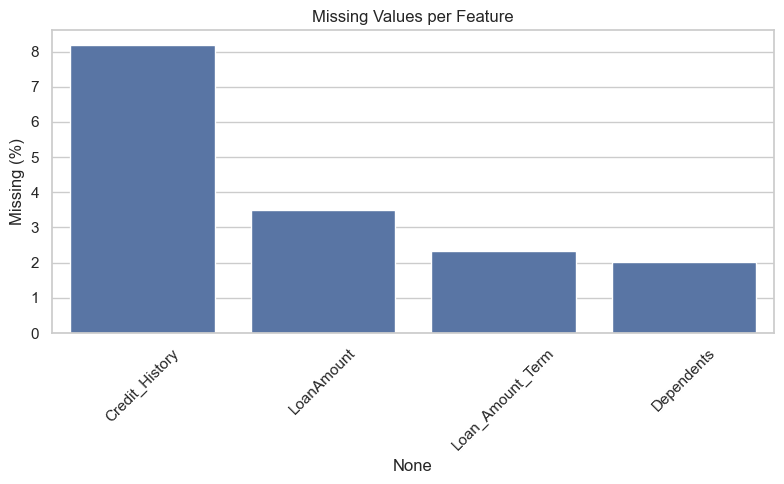

In [14]:
# 1.7 Visualize missing values as a bar chart

missing_nonzero = missing_df[missing_df["missing_count"] > 0]

if not missing_nonzero.empty:
    plt.figure()
    sns.barplot(
        x=missing_nonzero.index,
        y=missing_nonzero["missing_percent"]
    )
    plt.xticks(rotation=45)
    plt.ylabel("Missing (%)")
    plt.title("Missing Values per Feature")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values in the dataset ")

In [15]:
# 1.8 Check the target distribution

TARGET_COL = "Loan_Status"  

if TARGET_COL in df.columns:
    print(df[TARGET_COL].value_counts(normalize=False))
    print("\nTarget distribution (%):")
    print((df[TARGET_COL].value_counts(normalize=True) * 100).round(2))
else:
    raise ValueError(f"Target column '{TARGET_COL}' not found. Change TARGET_COL to correct name.")

Loan_Status
Y    411
N    187
Name: count, dtype: int64

Target distribution (%):
Loan_Status
Y    68.73
N    31.27
Name: proportion, dtype: float64


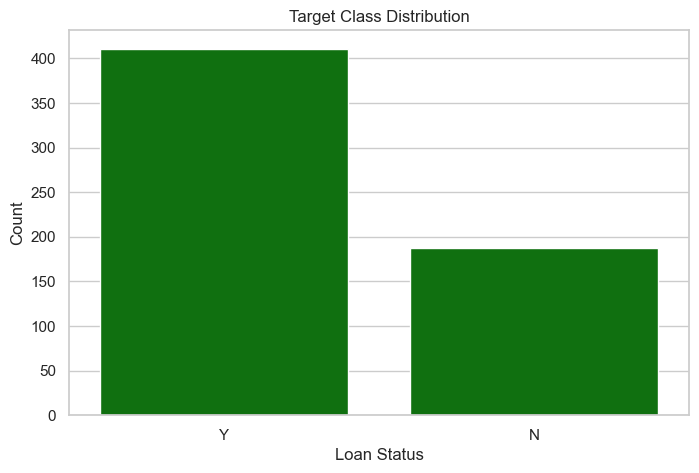

In [16]:
# 1.9 Visualize target balance

plt.figure()
sns.countplot(x=TARGET_COL, data=df , color='green')
plt.title("Target Class Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

#### Univariate analysis – Categorical features

This helps us see which categories are dominant and whether some categories are very rare (which can hurt model performance).

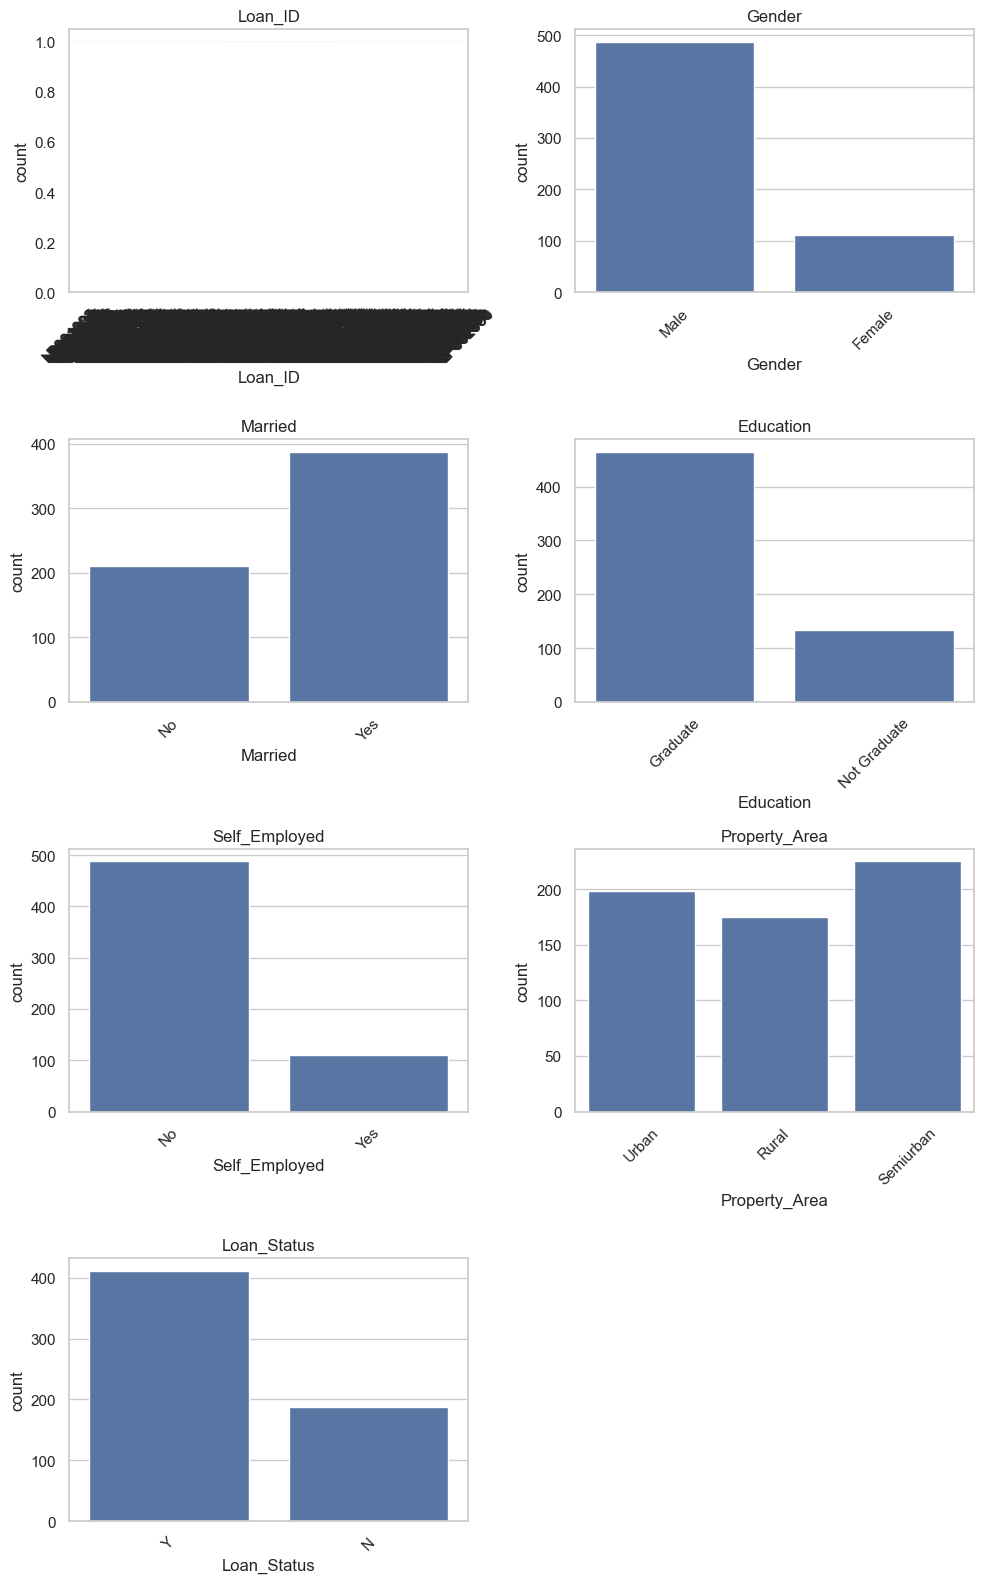

In [17]:
# 1.10 Countplots for categorical variables

n_cat = len(categorical_cols)
n_cols = 2
n_rows = int(np.ceil(n_cat / n_cols))

plt.figure(figsize=(10, 4 * n_rows))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Univariate analysis – Numerical features

checking distributions to see skewness, outliers, etc (log, scaling, etc.), which directly affects model loss.

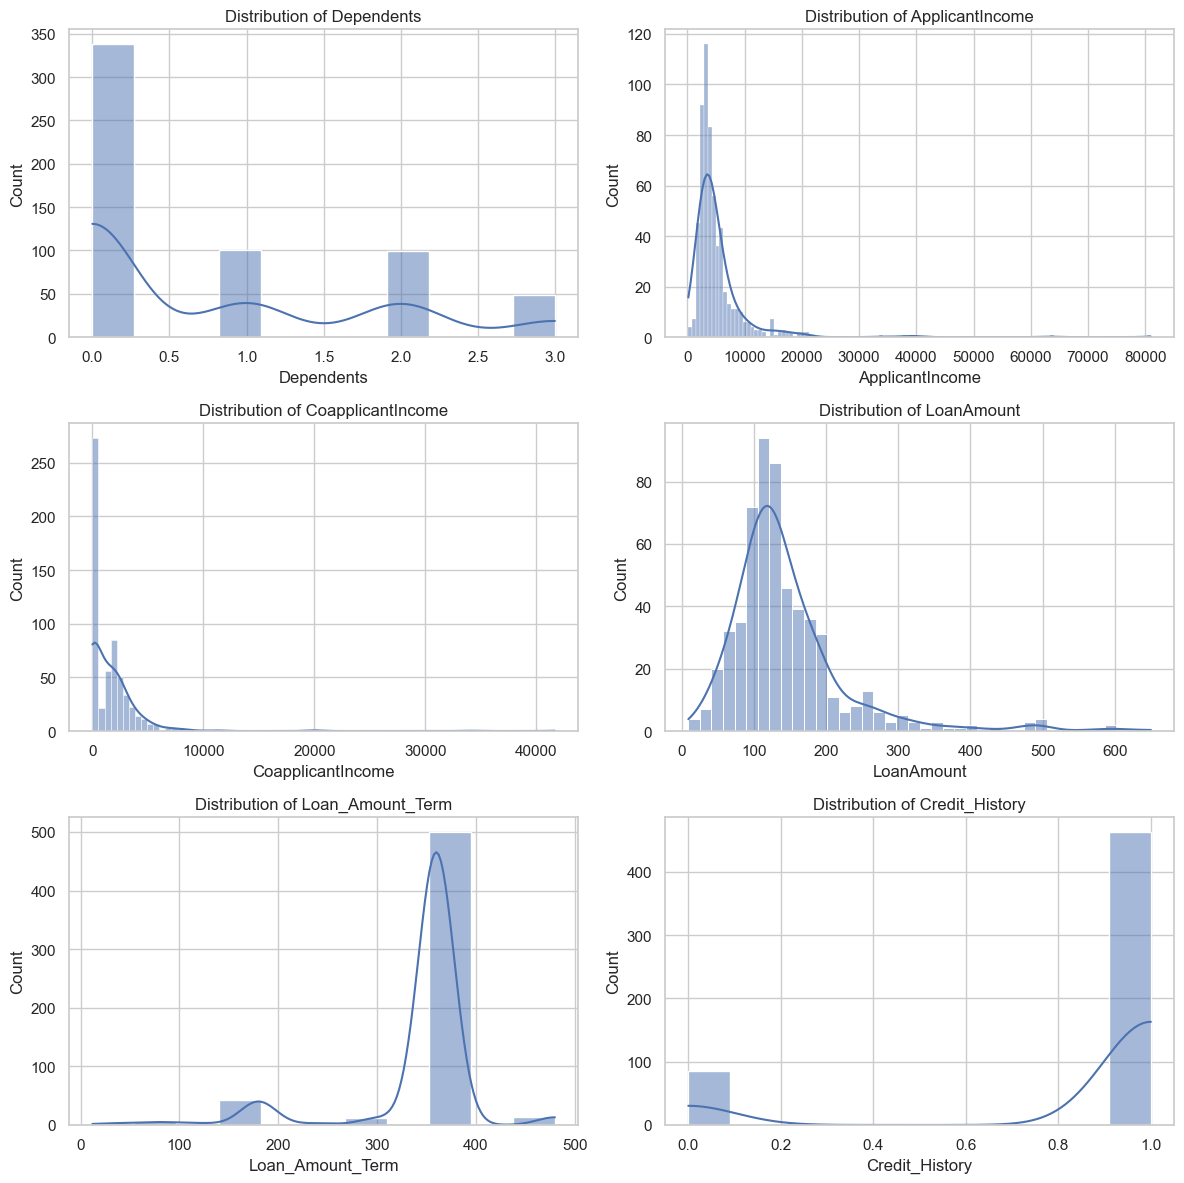

In [18]:
# 1.11 Histograms + KDE for numeric variables

n_num = len(numeric_cols)
n_cols = 2
n_rows = int(np.ceil(n_num / n_cols))

plt.figure(figsize=(12, 4 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

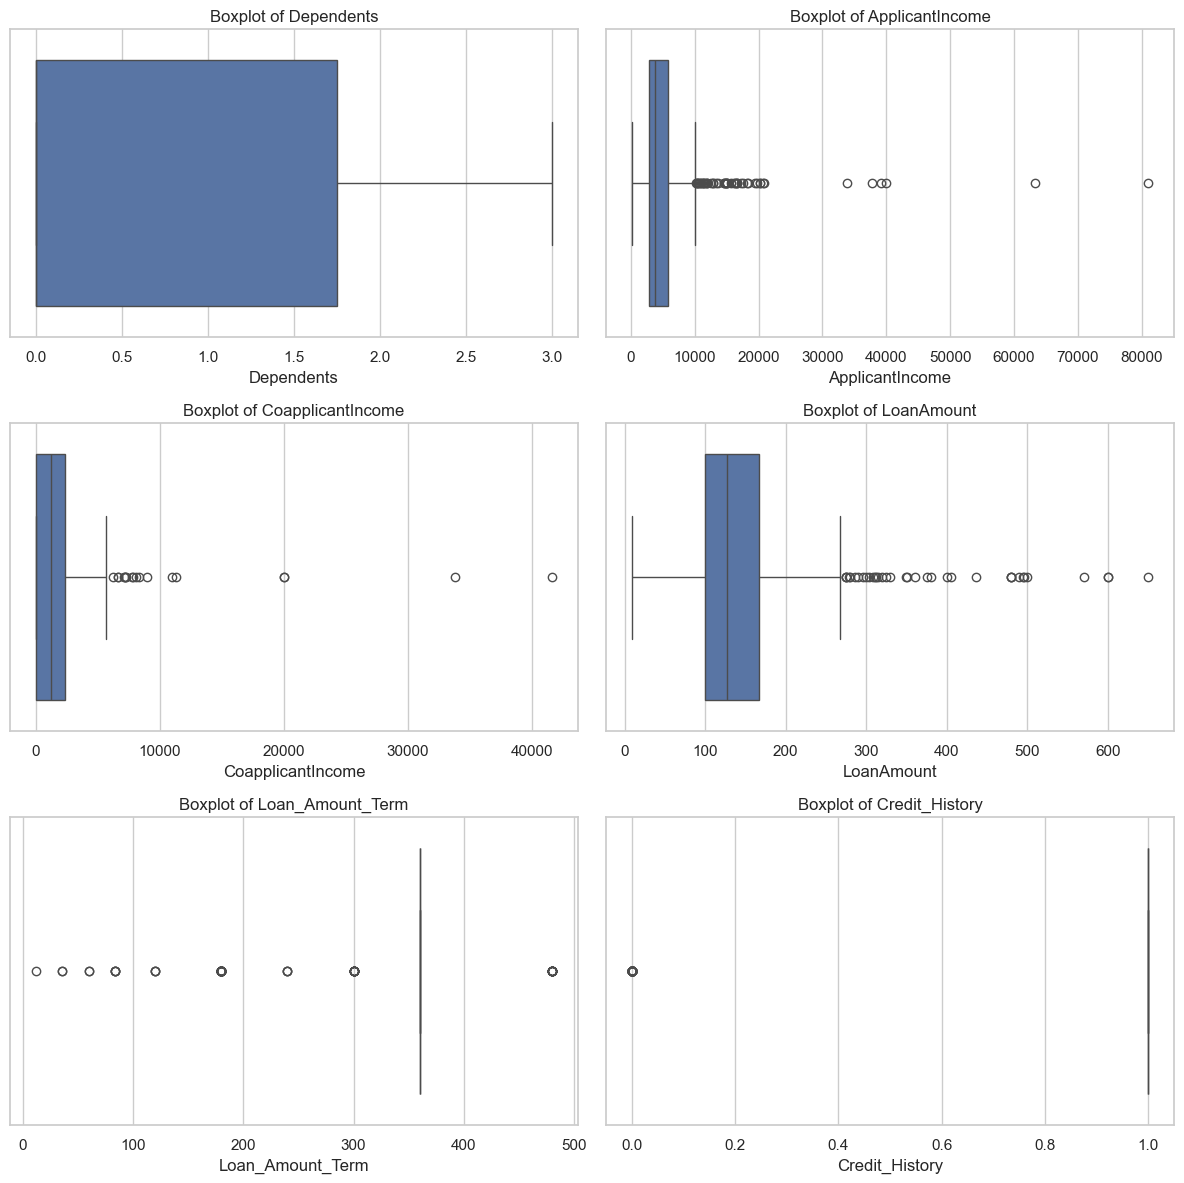

In [19]:
# 1.12 Boxplots to see outliers in numeric columns

plt.figure(figsize=(12, 4 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[col].dropna())
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

#### Relationship between features and target
These insights later help with feature engineering → better models → lower loss.

##### Categorical vs Target


<---- Loan_ID vs Loan_Status ---->


Loan_Status,N,Y
Loan_ID,,
LP001002,0.0,1.0
LP001003,1.0,0.0
LP001005,0.0,1.0
LP001006,0.0,1.0
LP001008,0.0,1.0
...,...,...
LP002978,0.0,1.0
LP002979,0.0,1.0
LP002983,0.0,1.0


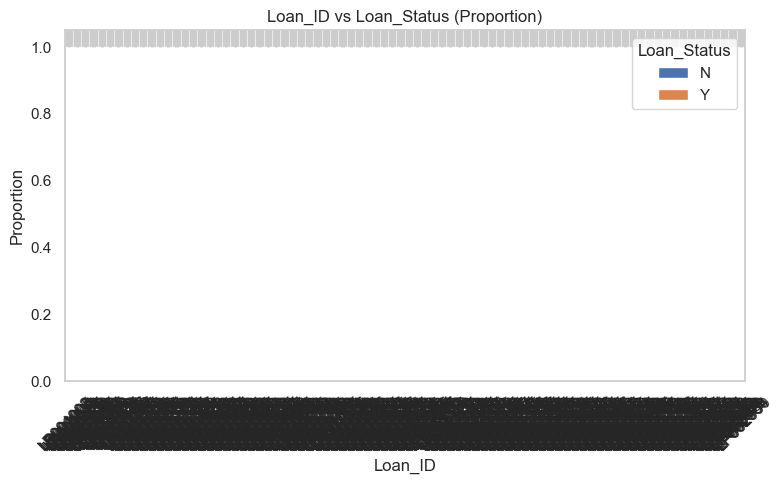


<---- Gender vs Loan_Status ---->


Loan_Status,N,Y
Gender,,
Female,0.333333,0.666667
Male,0.308008,0.691992


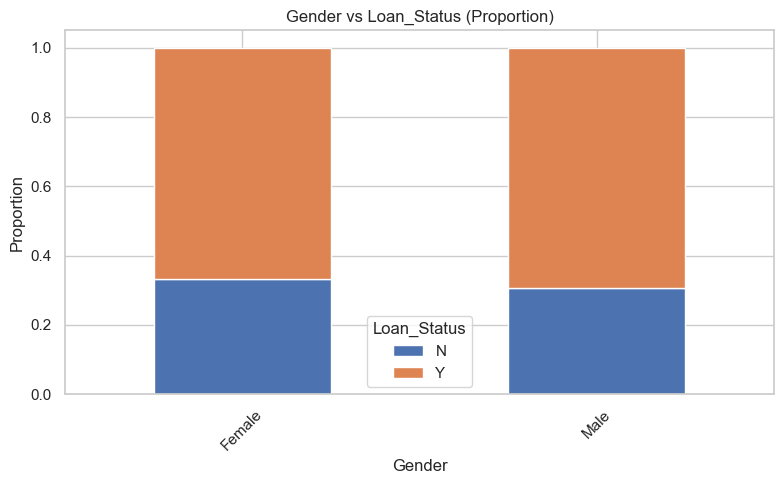


<---- Married vs Loan_Status ---->


Loan_Status,N,Y
Married,,
No,0.371429,0.628571
Yes,0.280928,0.719072


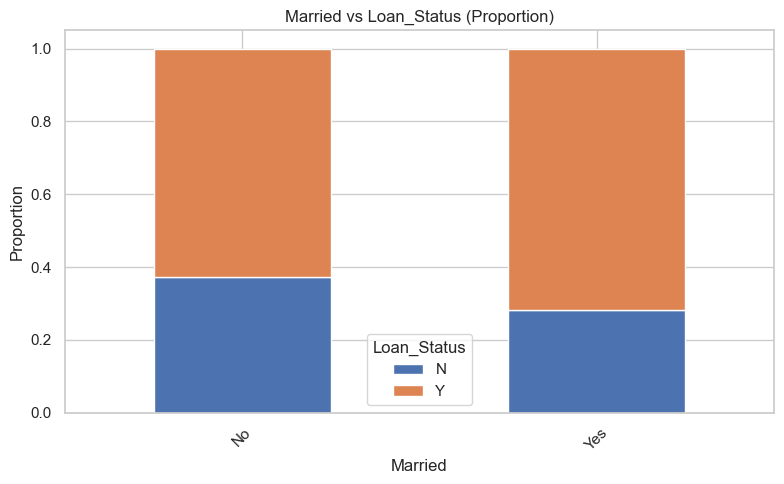


<---- Education vs Loan_Status ---->


Loan_Status,N,Y
Education,,
Graduate,0.292473,0.707527
Not Graduate,0.383459,0.616541


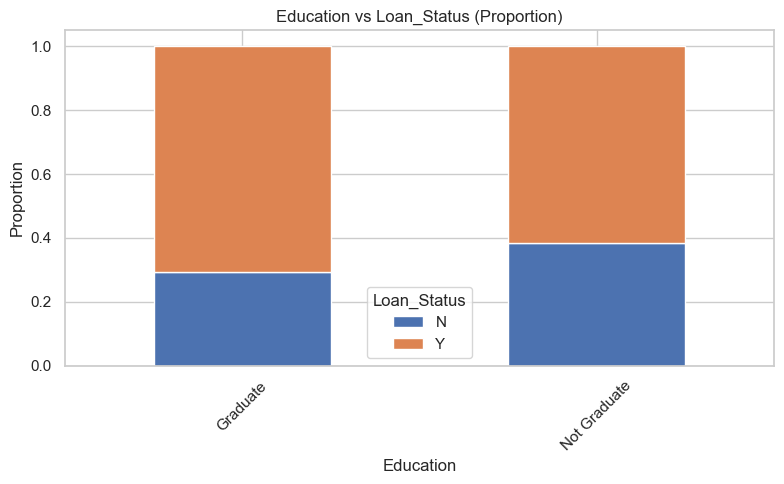


<---- Self_Employed vs Loan_Status ---->


Loan_Status,N,Y
Self_Employed,,
No,0.311475,0.688525
Yes,0.318182,0.681818


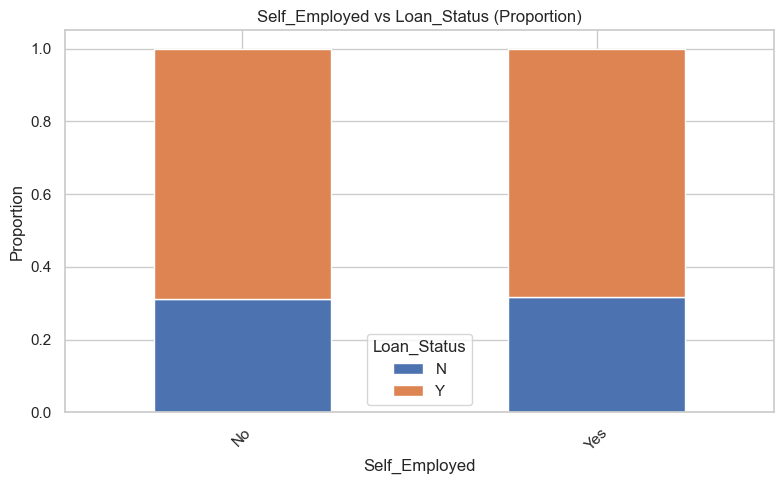


<---- Property_Area vs Loan_Status ---->


Loan_Status,N,Y
Property_Area,,
Rural,0.382857,0.617143
Semiurban,0.231111,0.768889
Urban,0.343434,0.656566


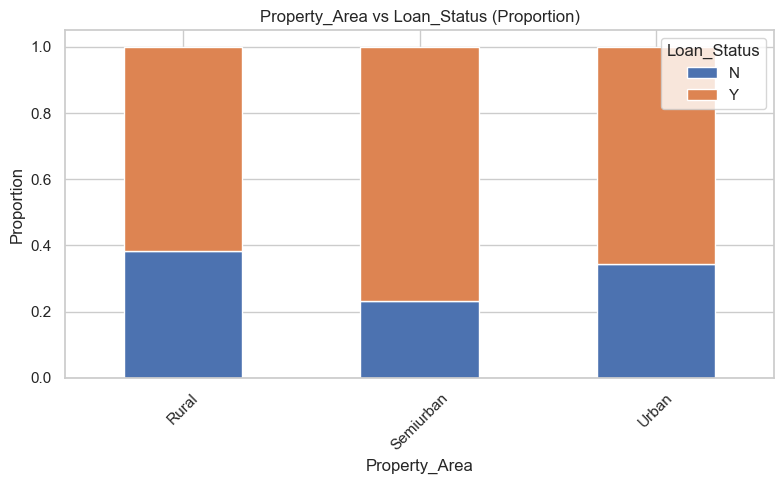

In [20]:
# 1.13 Categorical features vs Target (normalized bar plots)

for col in categorical_cols:
    if col == TARGET_COL:
        continue
    
    ct = pd.crosstab(df[col], df[TARGET_COL], normalize="index")
    print(f"\n<---- {col} vs {TARGET_COL} ---->")
    display(ct)
    
    ct.plot(kind="bar", stacked=True)
    plt.title(f"{col} vs {TARGET_COL} (Proportion)")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45)
    plt.legend(title=TARGET_COL)
    plt.tight_layout()
    plt.show()

##### Numeric vs Target

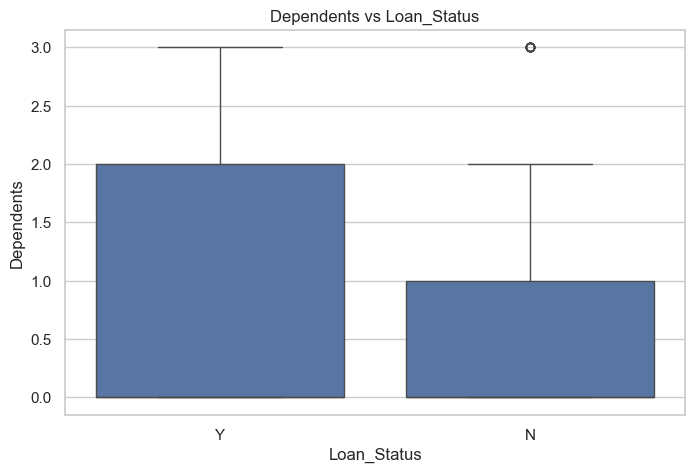

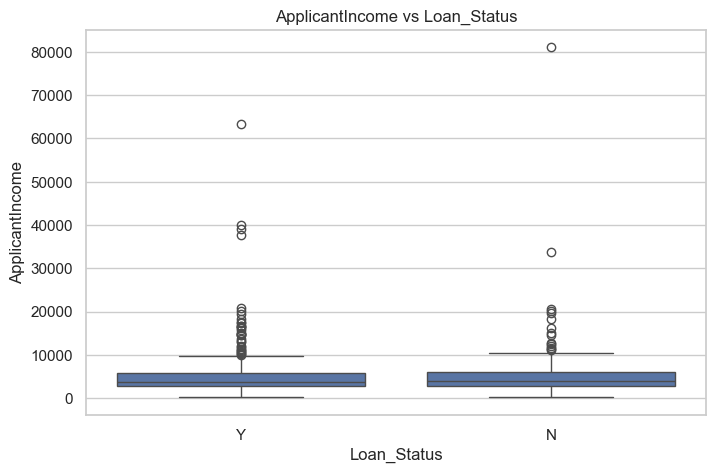

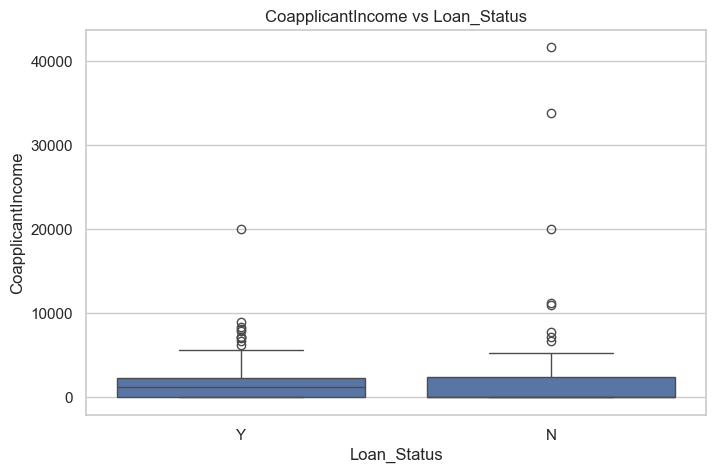

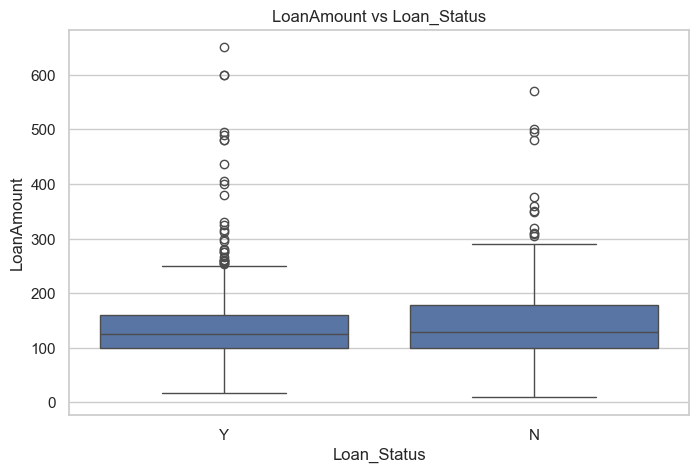

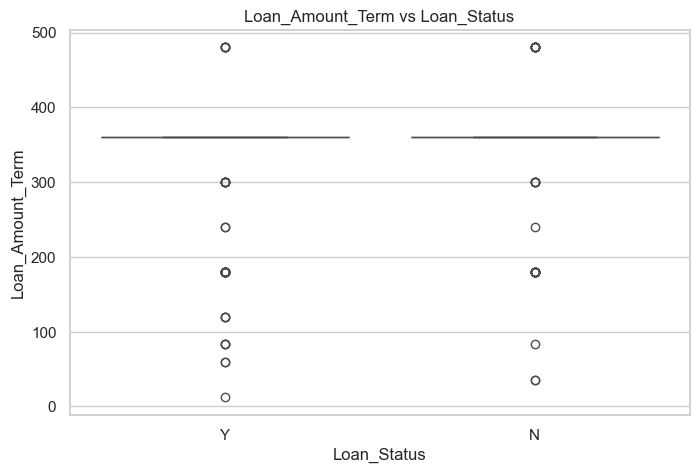

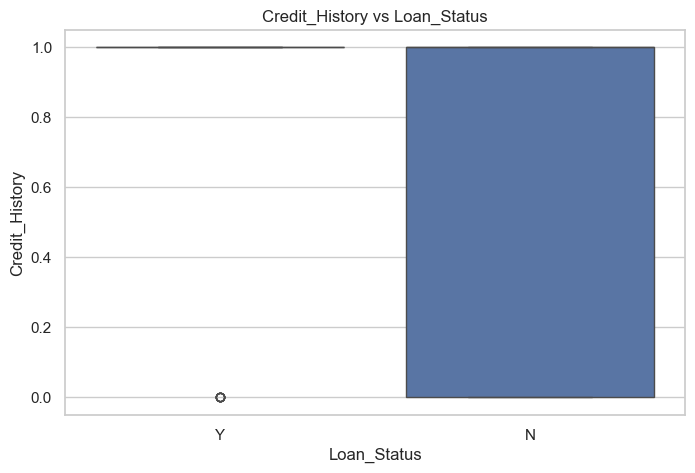

In [21]:
# 1.14 Numeric features vs Target (boxplots)

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=TARGET_COL, y=col, data=df)
    plt.title(f"{col} vs {TARGET_COL}")
    plt.show()

#### Correlation analysis (numeric features)

Helps us see multicollinearity and which features are strongly related to each other, which can affect models like linear/logistic regression.

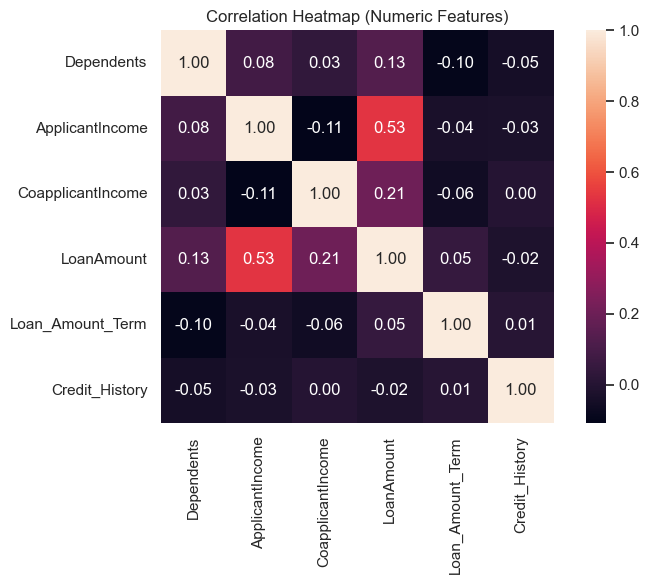

In [22]:
# 1.15 Correlation heatmap for numeric features

if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", square=True)
    plt.title("Correlation Heatmap (Numeric Features)")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns to compute correlation.")

#### DATA CLEANING + PREPROCESSING + FEATURE ENGINEERING

In [23]:
df_clean = df.copy()
print("Dataset copied for cleaning.")

Dataset copied for cleaning.


##### Handle Missing Values
handle numeric & categorical separately.

In [24]:
# Separate columns 
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Categorical columns: ['Loan_ID', 'Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


#### Impute Numeric Missing Values

Using median → more robust to outliers.

In [25]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")
df_clean[numeric_cols] = num_imputer.fit_transform(df_clean[numeric_cols])

print("Numeric missing values handled.")

Numeric missing values handled.


#### Impute Categorical Missing Values

Using most frequent (mode).

In [26]:
cat_imputer = SimpleImputer(strategy="most_frequent")
df_clean[categorical_cols] = cat_imputer.fit_transform(df_clean[categorical_cols])

print("Categorical missing values handled.")

Categorical missing values handled.


#### Fix Target Column (if needed)

We convert them into 1/0.

In [27]:
TARGET_COL = "Loan_Status" 

# If target column is like Y/N or Approved/Rejected
if df_clean[TARGET_COL].dtype == "object":
    df_clean[TARGET_COL] = df_clean[TARGET_COL].map({
        "Y": 1, "N": 0, 
        "Approved": 1, "Rejected": 0
    }).fillna(df_clean[TARGET_COL])

df_clean[TARGET_COL] = df_clean[TARGET_COL].astype(int)
print(df_clean[TARGET_COL].value_counts())

Loan_Status
1    411
0    187
Name: count, dtype: int64


#### Feature Engineering 

FEATURE 1 — Total Income

In [28]:
# If dataset has ApplicantIncome + CoapplicantIncome
if "ApplicantIncome" in df_clean.columns and "CoapplicantIncome" in df_clean.columns:
    df_clean["TotalIncome"] = df_clean["ApplicantIncome"] + df_clean["CoapplicantIncome"]

FEATURE 2 — Income to Loan Ratio

In [29]:
if "LoanAmount" in df_clean.columns:
    df_clean["Loan_Income_Ratio"] = df_clean["TotalIncome"] / df_clean["LoanAmount"]

FEATURE 3 — Family Size

In [30]:
if "Dependents" in df_clean.columns:
    df_clean["Dependents"] = df_clean["Dependents"].replace("3+", 3).astype(int)

    df_clean["FamilySize"] = df_clean["Dependents"] + 1

FEATURE 4 — EMI (Monthly Installment)

In [31]:
if "LoanAmount" in df_clean.columns and "Loan_Amount_Term" in df_clean.columns:
    df_clean["EMI"] = df_clean["LoanAmount"] / df_clean["Loan_Amount_Term"]

FEATURE 5 — Balance Income After EMI

In [32]:
if "EMI" in df_clean.columns:
    df_clean["Balance_Income"] = df_clean["TotalIncome"] - df_clean["EMI"]

In [33]:
# displaying all the added features
df_clean.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,Loan_Income_Ratio,FamilySize,EMI,Balance_Income
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,127.0,360.0,1.0,Urban,1,5849.0,46.055118,1,0.352778,5848.647222
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,0,6091.0,47.585938,2,0.355556,6090.644444
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,1,3000.0,45.454545,1,0.183333,2999.816667
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,1,4941.0,41.175000,1,0.333333,4940.666667
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,1,6000.0,42.553191,1,0.391667,5999.608333


In [34]:
# Drop Loan_ID or any unique identifier
if "Loan_ID" in df_clean.columns:
    df_clean.drop("Loan_ID", axis=1, inplace=True)
    print("Dropped Loan_ID column.")
else:
    print("Loan_ID column not found — skipping.")

Dropped Loan_ID column.


#### Encode Categorical Features

We use OneHotEncoder for categorical features.

In [35]:
# ENCODING CATEGORICAL FEATURES (ONE-HOT ENCODING)
from sklearn.preprocessing import OneHotEncoder

if "Loan_ID" in df_clean.columns:
    df_clean.drop("Loan_ID", axis=1, inplace=True)
    print("Dropped Loan_ID column.")

categorical_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()

# Remove target column from categorical list
categorical_cols = [c for c in categorical_cols if c != TARGET_COL]

print("Categorical columns to encode:", categorical_cols)

# Apply OneHotEncoder
ohe = OneHotEncoder(drop="first", sparse_output=False)

encoded_array = ohe.fit_transform(df_clean[categorical_cols])

# Convert encoded array into DataFrame
encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(categorical_cols),
    index=df_clean.index  # keep original row alignment
)

print("Encoding complete. Encoded shape:", encoded_df.shape)
encoded_df.head()


Categorical columns to encode: ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
Encoding complete. Encoded shape: (598, 6)


,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,1.0,0.0,0.0,0.0,0.0,1.0
1,1.0,1.0,0.0,0.0,0.0,0.0
2,1.0,1.0,0.0,1.0,0.0,1.0
3,1.0,1.0,1.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,1.0


#### Combine Encoded Data with Numeric Data

In [36]:
df_final = pd.concat(
    [df_clean[numeric_cols], encoded_df, df_clean[[TARGET_COL]]],
    axis=1
)

print("Final shape after encoding:", df_final.shape)
df_final.head()

Final shape after encoding: (598, 13)


,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status
0,0,5849.0,0.0,127.0,360.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1
1,1,4583.0,1508.0,128.0,360.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0
2,0,3000.0,0.0,66.0,360.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1
3,0,2583.0,2358.0,120.0,360.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1
4,0,6000.0,0.0,141.0,360.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1


#### Scale Numerical Features

Scaling is critical for neural networks, XGBoost, SVM, etc.

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_final[numeric_cols] = scaler.fit_transform(df_final[numeric_cols])

print("Feature scaling completed.")

Feature scaling completed.


#### Train/Test Split

In [38]:
from sklearn.model_selection import train_test_split

X = df_final.drop(TARGET_COL, axis=1)
y = df_final[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((478, 12), (120, 12))

#### MODEL TRAINING + EVALUATION 

Importing ML libraries

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#### Helper Function — Evaluate Models

In [41]:
def evaluate_model(model_name, y_true, y_pred, y_prob=None):
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
    }

    if y_prob is not None:
        try:
            metrics["ROC_AUC"] = roc_auc_score(y_true, y_prob)
        except:
            metrics["ROC_AUC"] = None
    else:
        metrics["ROC_AUC"] = None

    return metrics

##### Model 1 — Logistic Regression

In [44]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

lr_results = evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
lr_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.8083333333333333,
 'Precision': 0.7920792079207921,
 'Recall': 0.975609756097561,
 'F1 Score': 0.8743169398907104,
 'ROC_AUC': np.float64(0.8395378690629012)}

##### Model 2 — Random Forest

In [45]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

rf_results = evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)
rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.8083333333333333,
 'Precision': 0.7920792079207921,
 'Recall': 0.975609756097561,
 'F1 Score': 0.8743169398907104,
 'ROC_AUC': np.float64(0.8417843388960206)}

#### Model 3 — Gradient Boosting Classifier

In [46]:
gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

gb_results = evaluate_model("Gradient Boosting", y_test, y_pred_gb, y_prob_gb)
gb_results

{'Model': 'Gradient Boosting',
 'Accuracy': 0.8166666666666667,
 'Precision': 0.8061224489795918,
 'Recall': 0.9634146341463414,
 'F1 Score': 0.8777777777777778,
 'ROC_AUC': np.float64(0.8520539152759949)}

##### Compare All Models

In [47]:
results_df = pd.DataFrame([lr_results, rf_results, gb_results])
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC_AUC
0,Logistic Regression,0.808333,0.792079,0.975610,0.874317,0.839538
1,Random Forest,0.808333,0.792079,0.975610,0.874317,0.841784
2,Gradient Boosting,0.816667,0.806122,0.963415,0.877778,0.852054


#### Confusion Matrix (show for the best model)

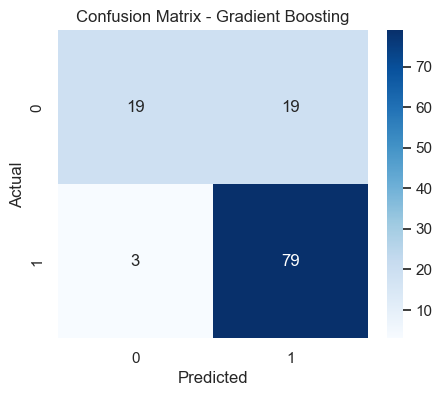

In [48]:
cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##### ROC Curve (Gradient Boosting)

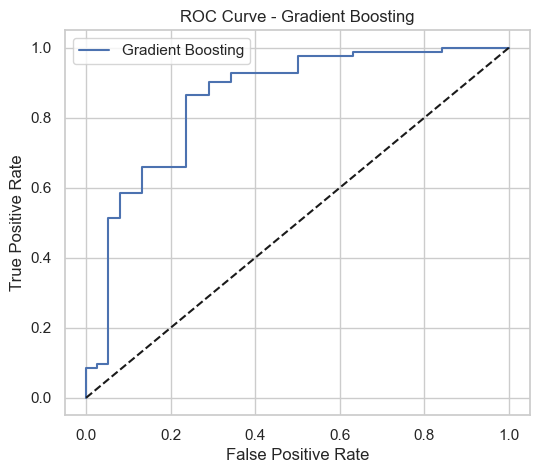

In [49]:
fpr, tpr, _ = roc_curve(y_test, y_prob_gb)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Gradient Boosting")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.show()

#### Feature Importance (Random Forest + Gradient Boosting)
Random Forest Feature Importance

In [50]:
rf_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

rf_importance.head(15)

Credit_History             0.420347
ApplicantIncome            0.144737
LoanAmount                 0.131896
CoapplicantIncome          0.101027
Loan_Amount_Term           0.051218
Dependents                 0.037850
Property_Area_Semiurban    0.023947
Married_Yes                0.023185
Education_Not Graduate     0.018814
Self_Employed_Yes          0.017499
Property_Area_Urban        0.014861
Gender_Male                0.014619
dtype: float64

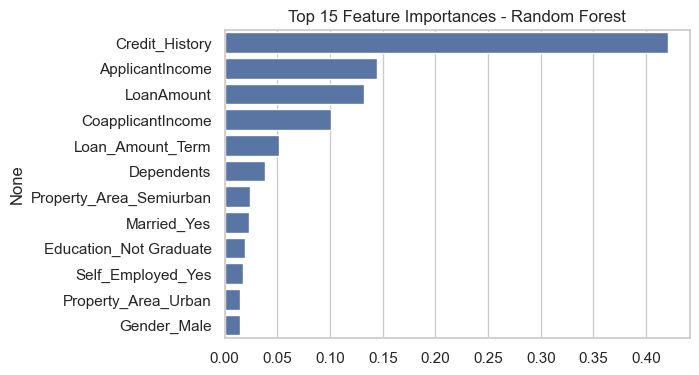

In [52]:
plt.figure(figsize=(6,4))
sns.barplot(
    x=rf_importance.values[:15],
    y=rf_importance.index[:15]
)
plt.title("Top 15 Feature Importances - Random Forest")
plt.show()

Gradient Boosting Feature Importance

In [53]:
gb_importance = pd.Series(
    gb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

gb_importance.head(15)

Credit_History             0.419272
ApplicantIncome            0.173482
LoanAmount                 0.171593
CoapplicantIncome          0.128611
Loan_Amount_Term           0.039761
Married_Yes                0.018312
Property_Area_Semiurban    0.013702
Dependents                 0.010376
Property_Area_Urban        0.009136
Self_Employed_Yes          0.008332
Education_Not Graduate     0.005266
Gender_Male                0.002159
dtype: float64

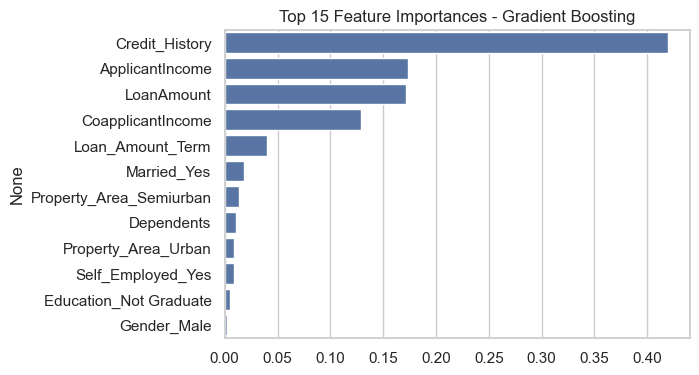

In [55]:
plt.figure(figsize=(6,4))
sns.barplot(
    x=gb_importance.values[:15],
    y=gb_importance.index[:15]
)
plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.show()

#### HYPERPARAMETER TUNING + MODEL STACKING + ERROR ANALYSIS

Import Required Libraries

In [56]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd

##### Hyperparameter Tuning — Logistic Regression

In [57]:
param_lr = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_lr,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
print("Best Logistic Regression:", grid_lr.best_params_)

Best Logistic Regression: {'C': 0.01, 'solver': 'liblinear'}


##### Hyperparameter Tuning — Random Forest

In [58]:
param_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_rf,
    cv=5,
    n_iter=20,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print("Best Random Forest:", grid_rf.best_params_)

Best Random Forest: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10}


##### Hyperparameter Tuning — Gradient Boosting

In [59]:
param_gb = {
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.7, 0.8, 1.0]
}

grid_gb = RandomizedSearchCV(
    GradientBoostingClassifier(),
    param_gb,
    cv=5,
    n_iter=15,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_
print("Best Gradient Boosting:", grid_gb.best_params_)

Best Gradient Boosting: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.01}


##### Compare Tuned Models

In [60]:
models = {
    "Logistic Regression (Tuned)": best_lr,
    "Random Forest (Tuned)": best_rf,
    "Gradient Boosting (Tuned)": best_gb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
    except:
        y_prob = None

    res = evaluate_model(name, y_test, y_pred, y_prob)
    results.append(res)

tuned_results_df = pd.DataFrame(results)
tuned_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC_AUC
0,Logistic Regression (Tuned),0.808333,0.792079,0.97561,0.874317,0.813543
1,Random Forest (Tuned),0.808333,0.792079,0.97561,0.874317,0.834403
2,Gradient Boosting (Tuned),0.800000,0.784314,0.97561,0.869565,0.812420


### Stacking Ensemble 

Ensemble of tuned models → usually gives the BEST accuracy + F1 score.

In [61]:
stack_model = StackingClassifier(
    estimators=[
        ("lr", best_lr),
        ("rf", best_rf),
        ("gb", best_gb)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method="predict_proba"
)

stack_model.fit(X_train, y_train)

y_pred_stack = stack_model.predict(X_test)
y_prob_stack = stack_model.predict_proba(X_test)[:, 1]

stack_results = evaluate_model("Stacking Ensemble", y_test, y_pred_stack, y_prob_stack)
stack_results

{'Model': 'Stacking Ensemble',
 'Accuracy': 0.8083333333333333,
 'Precision': 0.7920792079207921,
 'Recall': 0.975609756097561,
 'F1 Score': 0.8743169398907104,
 'ROC_AUC': np.float64(0.8395378690629012)}

#### Error Analysis (Where the model fails)

In [62]:
error_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_stack
})

error_df["Correct"] = error_df["Actual"] == error_df["Predicted"]

print("Incorrect Predictions:")
error_df[~error_df["Correct"]].head(20)

Incorrect Predictions:


,Actual,Predicted,Correct
555,0,1,False
409,0,1,False
187,0,1,False
514,1,0,False
56,0,1,False
567,0,1,False
393,0,1,False
505,0,1,False
158,0,1,False
333,0,1,False


##### Classification Report

In [63]:
print(classification_report(y_test, y_pred_stack))

              precision    recall  f1-score   support

           0       0.89      0.45      0.60        38
           1       0.79      0.98      0.87        82

    accuracy                           0.81       120
   macro avg       0.84      0.71      0.74       120
weighted avg       0.82      0.81      0.79       120



##### Final Comparison (All Models)

In [64]:
final_df = pd.concat([tuned_results_df, pd.DataFrame([stack_results])], ignore_index=True)
final_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC_AUC
0,Logistic Regression (Tuned),0.808333,0.792079,0.97561,0.874317,0.813543
1,Random Forest (Tuned),0.808333,0.792079,0.97561,0.874317,0.834403
2,Gradient Boosting (Tuned),0.800000,0.784314,0.97561,0.869565,0.812420
3,Stacking Ensemble,0.808333,0.792079,0.97561,0.874317,0.839538


##### SHAP Explainability (Global + Local)

In [66]:
import shap

# SHAP only works well with tree models → use tuned Gradient Boosting
explainer = shap.TreeExplainer(best_gb)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

shap_values[:5]  # sanity check

array([[ 2.52868090e-04,  2.72337952e-02, -7.74327218e-03,
         3.44255117e-02,  5.68165189e-03,  2.84912040e-01,
         0.00000000e+00,  2.56200510e-02,  1.47432605e-03,
         0.00000000e+00, -9.05149412e-03,  0.00000000e+00],
       [-1.14198492e-04,  1.57782733e-02,  8.55824430e-03,
         5.86236502e-03,  5.68165189e-03,  2.82030101e-01,
         0.00000000e+00,  2.56200510e-02,  1.47432605e-03,
         0.00000000e+00, -9.05149412e-03,  0.00000000e+00],
       [-1.14198492e-04,  1.57782733e-02,  8.55824430e-03,
        -3.65768170e-02,  3.31890122e-03,  2.79487596e-01,
         0.00000000e+00,  2.56200510e-02,  1.47432605e-03,
         0.00000000e+00,  1.34057656e-02,  0.00000000e+00],
       [-1.14198492e-04,  3.01483223e-02, -7.74327218e-03,
         4.56820502e-02,  3.31890122e-03,  2.80199200e-01,
         0.00000000e+00, -4.72031072e-02,  1.47432605e-03,
         0.00000000e+00, -9.05149412e-03,  0.00000000e+00],
       [ 2.52868090e-04,  3.74093218e-03,  7.6426366

#### SHAP Summary Plot (Global Feature Importance)

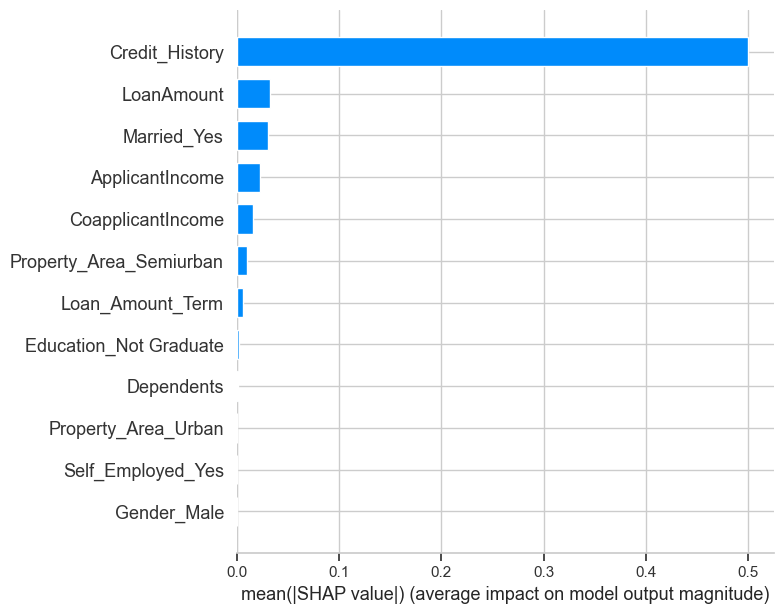

In [67]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

##### SHAP Beeswarm Plot (How features influence predictions)

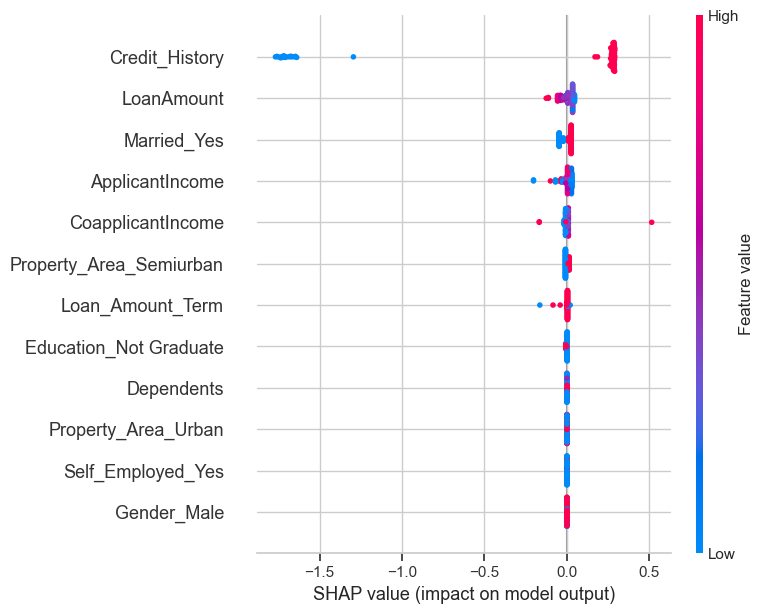

In [68]:
shap.summary_plot(shap_values, X_test)

##### SHAP Local Explanation (Force Plot for One Instance)

In [69]:
i = 10  # example index
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_test.iloc[i]
)

##### SAVE the Final Stacking Model

In [71]:
import joblib

joblib.dump(stack_model, "loan_approval_model.pkl")
print("Model saved as loan_approval_model.pkl")

Model saved as loan_approval_model.pkl
